In [50]:
from src.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH

import numpy as np
import pandas as pd
import pynapple as nap
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors

import umap
import umap.plot

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)
unit_id = "116b"

prj = nap.load_folder(PROCESSED_DATA_PATH.parent)
prj.view

📂 ucsf
├── 📂 external
│   └── 📂 107b
├── 📂 interim
│   └── 📂 107b
│       ├── 📂 umap_correlation
│       ├── 📂 umap_cosine
│       ├── 📂 umap_euclidean
│       ├── 📂 umap_mahalanobis
│       ├── 📂 umap_manhattan
│       ├── hd_burst_epochs.npz     |        IntervalSet
│       └── hd_pop_zrate.npz        |        Tsd
├── 📂 processed
│   ├── 📂 107b
│   │   ├── active_wake.npz         |        IntervalSet
│   │   ├── angle_openfield.npz     |        Tsd
│   │   ├── hd_spikes_openfield.npz         |        TsdFrame
│   │   ├── hd_spikes_total.npz     |        TsGroup
│   │   ├── position_neck.npz       |        TsdFrame
│   │   ├── pupil_full_data.npz     |        TsdFrame
│   │   ├── pupil_full_normalized.npz       |        TsdFrame
│   │   ├── pupil_nrem.npz  |        TsdFrame
│   │   ├── pupil_nrem_normalized.npz       |        TsdFrame
│   │   ├── sleep.npz       |        IntervalSet
│   │   ├── spikes_shank_1.npz      |        TsGroup
│   │   ├── spikes_shank_2.npz      |        TsGroup
│   │   ├── spikes_shank_3.npz      |        TsGroup
│   │   └── turn_spikes.npz         |        TsGroup
│   └── 📂 116b
│       ├── angle_openfield.npz     |        Tsd
│       ├── hd_spikes_total.npz     |        TsGroup
│       ├── hd_spikes_wake_pre_ttx.npz      |        TsGroup
│       ├── manifold_outliers_wake_pre_ttx.npz      |        IntervalSet
│       ├── manifold_wake_pre_ttx.npz       |        TsdFrame
│       ├── sleep.npz       |        IntervalSet
│       ├── spikes_shank_1.npz      |        TsGroup
│       ├── spikes_shank_2.npz      |        TsGroup
│       ├── spikes_shank_3.npz      |        TsGroup
│       └── spikes_shank_4.npz      |        TsGroup
└── 📂 raw
    ├── 📂 107b
    └── 📂 116b

### Load data

In [51]:
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_total.npz")
hd_angle        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")

In [52]:
from scipy.io import loadmat
sessions = loadmat(PROCESSED_DATA_PATH / unit_id / "session_epochs.mat")["session_epochs"].squeeze()
sessions = nap.IntervalSet(start=sessions[:, 0], end=sessions[:, 1], time_units='s')
sessions

  index     start       end
      0      0      1551.35
      1   1551.35  16644.5
      2  16644.5   18783.1
      3  18783.1   21454
      4  21454     22244.2
      5  22244.2   62109.4
      6  62109.4   63443.9
shape: (7, 2), time unit: sec.

In [53]:
epochs_pre_ttx = sleep_states[sleep_states['state'] == 'wake'].intersect(hd_angle.time_support)
epochs_post_ttx = sleep_states[sleep_states['state'] == 'wake'].intersect(sessions[4:6])
epochs_post_ttx

index    start        end          state
0        21453.9522   22244.2434   wake
1        22244.24345  23093.0      wake
2        23427.0      23475.0      wake
3        23894.0      24090.0      wake
4        24228.0      24241.0      wake
5        24449.0      24464.0      wake
6        24710.0      24725.0      wake
...      ...          ...          ...
185      60550.0      60563.0      wake
186      60764.0      60779.0      wake
187      61037.0      61113.0      wake
188      61162.0      61307.0      wake
189      61742.0      61751.0      wake
190      61897.0      61905.0      wake
191      61970.0      62109.35065  wake
shape: (192, 2), time unit: sec.

### Preprocessing

In [54]:
from scipy.signal.windows import gaussian

wake_bin = 0.1

kernel = gaussian(M=200, std=3)
epochs = epochs_pre_ttx
hd_angle = hd_angle.bin_average(bin_size=wake_bin, ep=epochs)
wake_binned = hd_spikes.count(bin_size=wake_bin, ep=epochs)
wake_rate1 = np.sqrt(wake_binned.convolve(kernel))

print(np.prod(wake_rate1.shape))
wake_rate1.shape

1708695


(21095, 81)

In [55]:
from scipy.signal.windows import gaussian

wake_bin = 0.1

kernel = gaussian(M=200, std=3)

epochs = epochs_post_ttx[:10]
# hd_angle = hd_angle.bin_average(bin_size=wake_bin, ep=epochs)
wake_binned = hd_spikes.count(bin_size=wake_bin, ep=epochs)
wake_rate2 = np.sqrt(wake_binned.convolve(kernel))

print(np.prod(wake_rate2.shape))
wake_rate2.shape

1596591


(19711, 81)

### Manifold analysis

<Axes: >

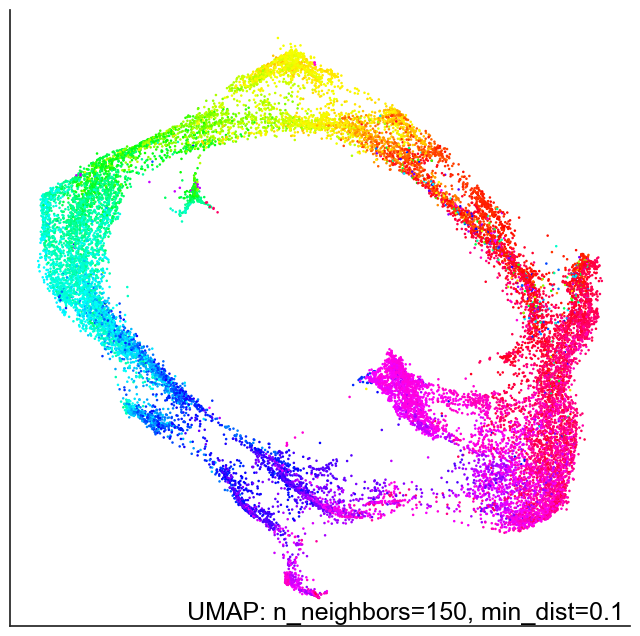

In [ ]:
reducer = umap.UMAP(n_neighbors=200,
                    min_dist=0.1,
                    n_components=2,
                    metric='euclidean'
                    )

wake_embds = reducer.fit_transform(wake_rate1)
umap.plot.points(reducer, values=hd_angle.values, cmap='hsv')

Pre TTX injection manifold

<Axes: >

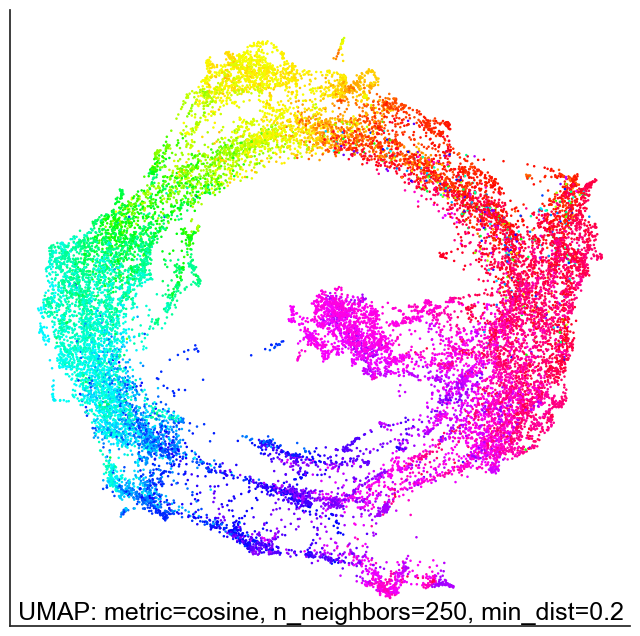

In [61]:
reducer = umap.UMAP(n_neighbors=250,
                    min_dist=0.2,
                    n_components=2,
                    metric='cosine'
                    )

wake_embds = reducer.fit(wake_rate1)
umap.plot.points(reducer, values=hd_angle.values, cmap='hsv')

Post TTX injection wake manifold

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\umap\plot.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(points[:, 0], points[:, 1], s=point_size, c=color)


<Axes: >

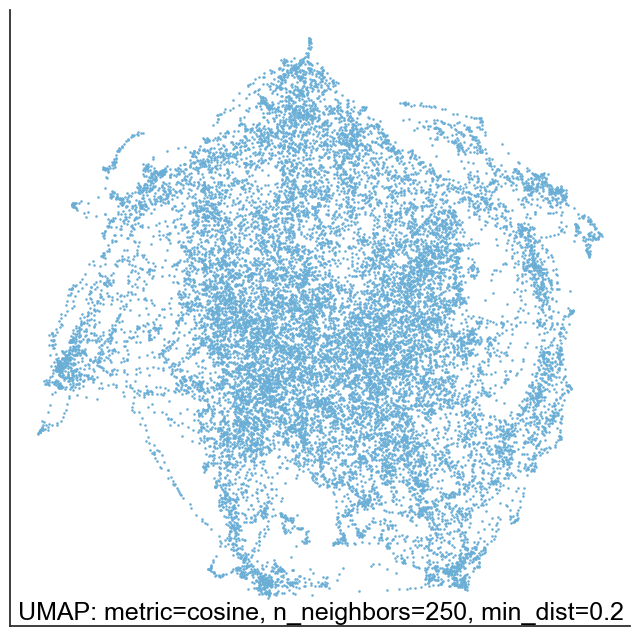

: 

In [ ]:
reducer2 = umap.UMAP(n_neighbors=250,
                    min_dist=0.2,
                    n_components=2,
                    metric='cosine'
                    )

wake_embds2 = reducer2.fit_transform(wake_rate2)
umap.plot.points(reducer2)

In [42]:
wake_embds2 = reducer1.transform(wake_rate2)

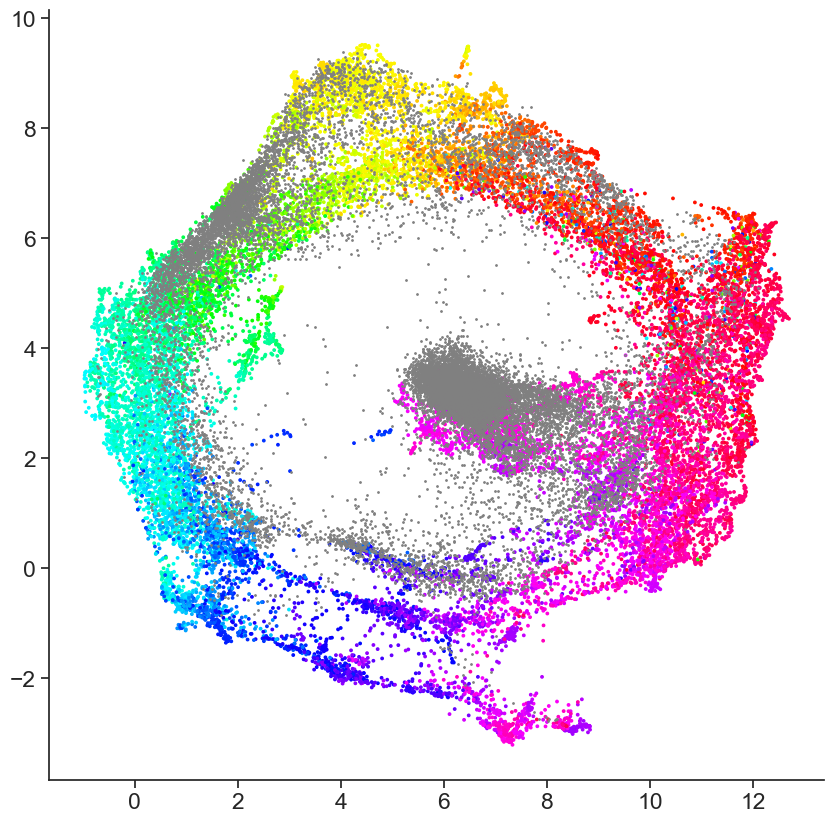

In [43]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(wake_embds[:, 0], wake_embds[:, 1], c=hd_angle.values, cmap='hsv', s=3)
ax.scatter(wake_embds2[:, 0], wake_embds2[:, 1], c='gray', s=1)

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\pynndescent\pynndescent_.py:1241: UserWarning: Failed to correctly find n_neighbors for some samples. Results may be less than ideal. Try re-running with different parameters.
  warn(


<Axes: >

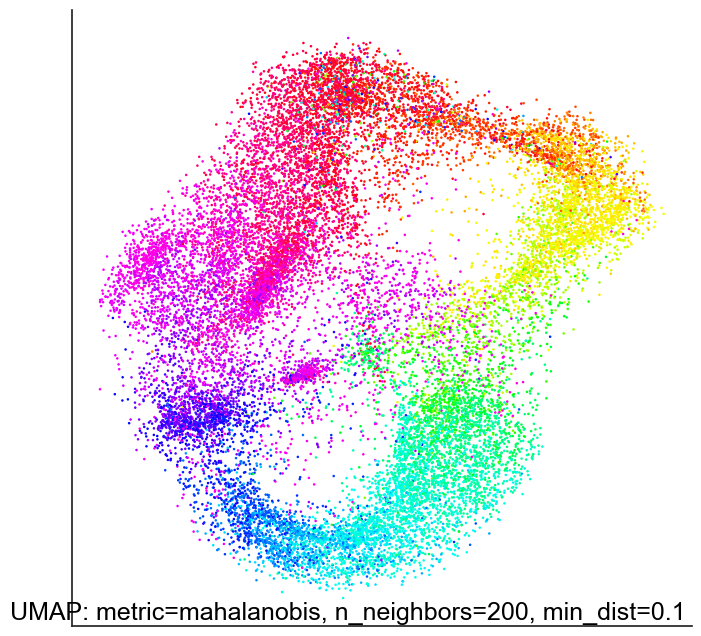

In [9]:
reducer = umap.UMAP(n_neighbors=200,
                    min_dist=0.1,
                    n_components=2,
                    metric='mahalanobis'
                    )

wake_embds = reducer.fit_transform(wake_rate)
umap.plot.points(reducer, values=hd_angle.values, cmap='hsv')

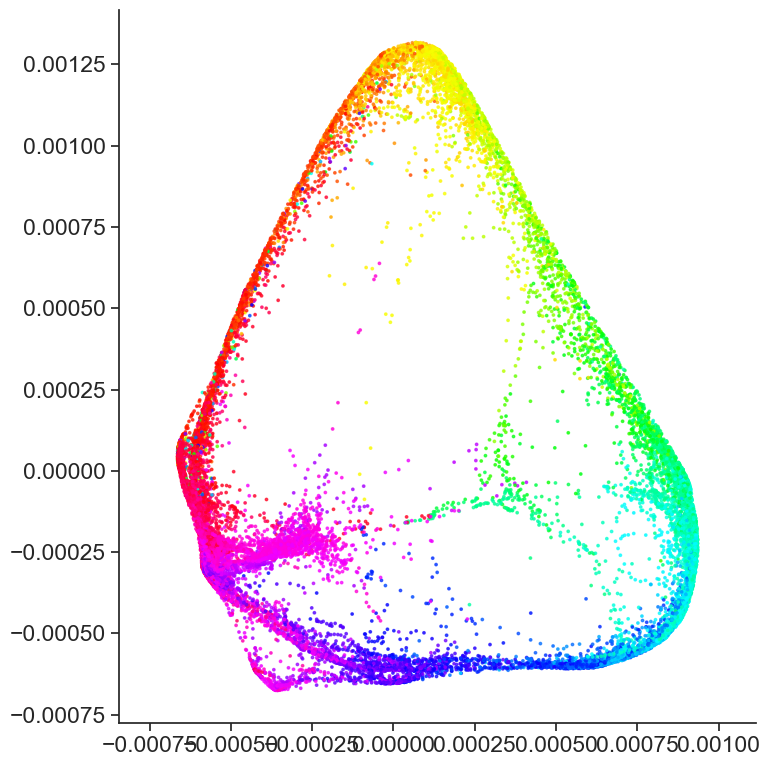

In [10]:
from sklearn.manifold import SpectralEmbedding as algorithm

model = algorithm(n_neighbors=150, n_components=2, n_jobs=-1)
wake_embd = model.fit_transform(wake_rate)

fig, ax = plt.subplots(figsize=(8, 8))

scatter = ax.scatter(wake_embd[:, 0], wake_embd[:, 1],
           s=3, c=hd_angle.values, cmap='hsv',
           alpha=0.7)

ax.axis('equal')
fig.tight_layout()

In [45]:
from sklearn.manifold import Isomap

model = Isomap(n_neighbors=200, n_components=2, n_jobs=-1)

wake_embd = model.fit_transform(wake_rate1)

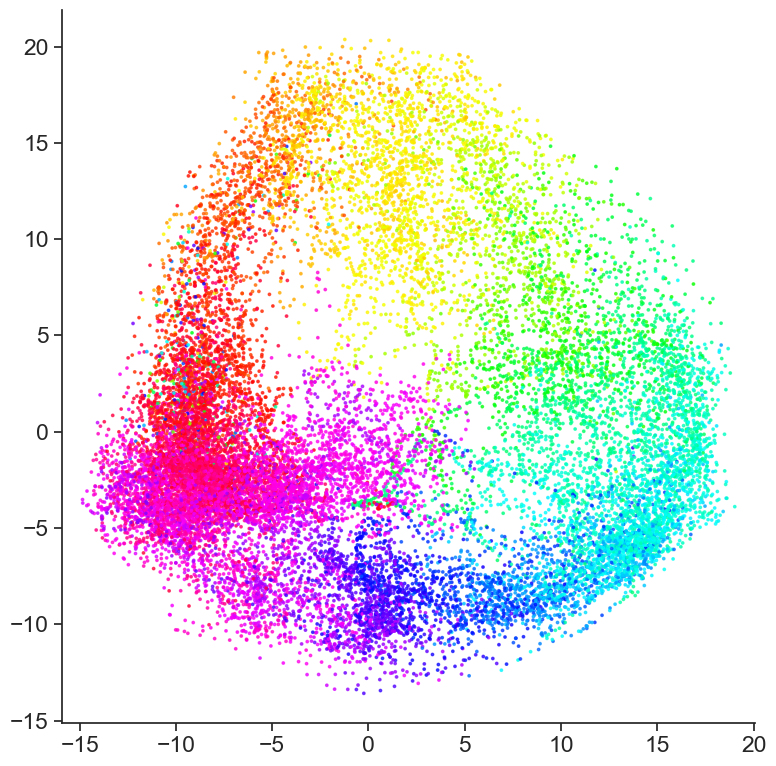

In [46]:
fig, ax = plt.subplots(figsize=(8, 8))

scatter = ax.scatter(wake_embd[:, 0], wake_embd[:, 1],
           s=3, c=hd_angle.values, cmap='hsv',
           alpha=0.7)

ax.axis('equal')
fig.tight_layout()

<Axes: ylabel='Count'>

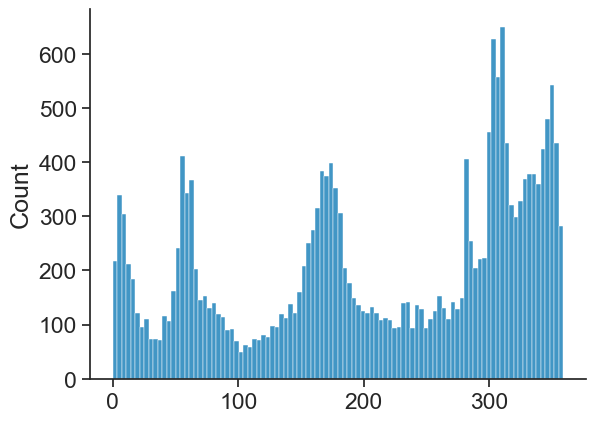

In [47]:
sns.histplot(hd_angle.values, bins=100)